In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("train.csv")
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[cols] = data[cols].fillna(data[cols].mean())
categorical_cols = ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
for col in categorical_cols:
    if col in data.columns:
        mode_val = data[col].mode()[0]  
        data[col] = data[col].fillna(mode_val)
data.isnull().sum()        

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [8]:
data[['Deck', 'CabinNumber', 'Side']] = data['Cabin'].str.split('/', expand=True)
data['CabinNumber'] = pd.to_numeric(data['CabinNumber'])
data[['Cabin', 'Deck', 'CabinNumber', 'Side']].head()
from sklearn.preprocessing import OrdinalEncoder
# One - Hot Encoding категориальных признаков
data_encoded = pd.get_dummies(
    data,
    columns=['HomePlanet', 'Destination'],
    prefix=['HomePlanet', 'Destination']
)
# Удаление ненужных столбцов
data_encoded = data_encoded.drop(columns=['Cabin', 'PassengerId', 'Name'])
# OrdinalEncoder оставшихся признаков
oe = OrdinalEncoder()
data_encoded[['Deck','Side']] = oe.fit_transform(data_encoded[['Deck','Side' ]])
col = data_encoded.pop('Transported')
data_encoded['Transported'] = col
data_encoded.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNumber,Side,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Transported
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,False,True,False,False,False,True,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,5.0,0,1.0,True,False,False,False,False,True,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0.0,0,1.0,False,True,False,False,False,True,False
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0.0,0,1.0,False,True,False,False,False,True,False
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,5.0,1,1.0,True,False,False,False,False,True,True


In [9]:
X = data_encoded.drop(columns=['Transported'])
y = data_encoded['Transported']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Бэггинг

In [19]:
Bag_model = BaggingClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
Bag_model.fit(X_train_scaled, y_train)
y_pred_bag = Bag_model.predict(X_test_scaled)
y_proba_bag = Bag_model.predict_proba(X_test_scaled)[:, 1]

# Случайный лес

In [43]:
RF_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
RF_model.fit(X_train_scaled, y_train)
y_pred_RF = RF_model.predict(X_test_scaled)
y_proba_RF = RF_model.predict_proba(X_test_scaled)[:, 1]

# Adaboost

In [36]:
Ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
Ada_model.fit(X_train_scaled, y_train)
y_pred_Ada = Ada_model.predict(X_test_scaled)
y_proba_Ada = Ada_model.predict_proba(X_test_scaled)[:, 1]

# Градиентный бустинг

In [22]:
Grad_b_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
Grad_b_model.fit(X_train_scaled, y_train)
y_pred_grad_b = Grad_b_model.predict(X_test_scaled)
y_proba_grad_b = Grad_b_model.predict_proba(X_test_scaled)[:, 1]

# Сравнение

               Model  Accuracy
0            Bagging  0.787234
1      Random Forest  0.793560
2           AdaBoost  0.765382
3  Gradient Boosting  0.788384


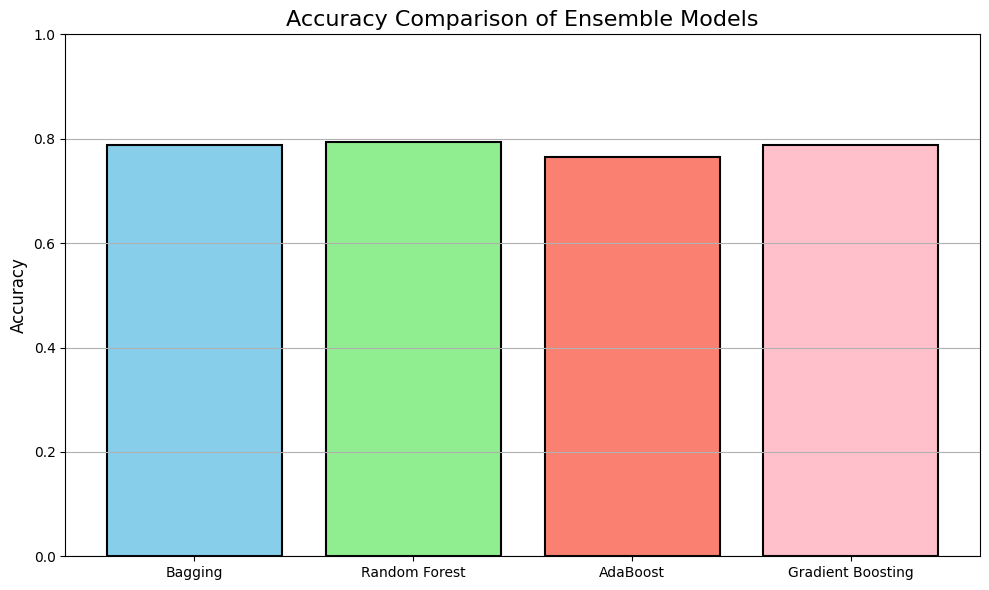

In [54]:
results = []
results.append({
    'Model': 'Bagging',
    'Accuracy': accuracy_score(y_test, y_pred_bag)

})

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_grad_b)
})

results.append({
    'Model': 'AdaBoost',
    'Accuracy': accuracy_score(y_test, y_pred_Ada)
})

results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_RF)
})

results_df = pd.DataFrame(results)

print(results_df)
colors = ['skyblue','lightgreen','salmon','pink']
plt.figure(figsize=(10, 6))
plt.bar(
    results_df['Model'],
    results_df['Accuracy'],
    color=colors,
    edgecolor='black',
    linewidth=1.5
)
plt.title("Accuracy Comparison of Ensemble Models", fontsize=16)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Вывод
### Случайный лес лучше всех)